# Swire Coca-Cola Preventative Maintenence

## Business Problem Statement

Swire Coca-Cola currently experiences unwanted downtime during the manufacturing process of
their products due to unforeseen breakdowns of various pieces within their bottling and canning
machines. This downtime accounts for an estimated 60 million dollars worth of losses on an
annual basis. Under their current system, engineers are deployed only reactively in response to
mechanical failures of production line machines, a slow process that ultimately needs to be
improved upon. Swire is looking to develop a model that can accurately alert employees of
issues along the production line in a manner that allows for repairs to be made prior to
catastrophic breakdowns that increase downtime in excess of what can be expected with timely
repairs.

## Exploratory Data Analysis

In [ ]:
import pandas as pd # import packages
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df.head() # load data and confirm worked

,ORDER_ID,PLANT_ID,PRODUCTION_LOCATION,EXECUTION_START_DATE,EXECUTION_FINISH_DATE,ACTUAL_START_TIME,ACTUAL_FINISH_TIME,ACTUAL_WORK_IN_MINUTES,MAINTENANCE_PLAN,MAINTENANCE_ITEM,...,FUNCTIONAL_AREA_NODE_2_MODIFIED,FUNCTIONAL_AREA_NODE_3_MODIFIED,FUNCTIONAL_AREA_NODE_4_MODIFIED,FUNCTIONAL_AREA_NODE_5_MODIFIED,EQUIPMENT_ID,EQUIPMENT_DESC,EQUIP_CAT_DESC,EQUIP_START_UP_DATE,EQUIP_VALID_FROM,EQUIP_VALID_TO
0,705642457,G812,ROMA,2024-05-04,2024-05-12,06:00:00.000,23:04:08.000,390.0,NaN,NaN,...,G812 PRD FILLER_ROTARY_CAN,G812 PRD FILLER_ROTARY_CAN LINE 3,CONVEYOR,FULL CAN CONVEYOR,300126812.0,FULL CAN CONVEYOR (FC41B),Machines,2020-04-22,2020-02-10,9999-12-31
1,704191697,G812,ROMA,2022-09-13,2022-09-13,06:00:00.000,17:17:24.000,420.0,NaN,NaN,...,G812 PRD FILLER_ROTARY_CAN,G812 PRD FILLER_ROTARY_CAN LINE 3,CONVEYOR,FULL CAN CONVEYOR,300126812.0,FULL CAN CONVEYOR (FC41B),Machines,2020-04-22,2020-02-10,9999-12-31
2,704466547,G812,ROMA,2022-12-21,2022-12-21,07:00:00.000,07:00:00.000,30.0,NaN,NaN,...,G812 PRD FILLER_ROTARY_CAN,G812 PRD FILLER_ROTARY_CAN LINE 3,CONVEYOR,FULL CAN CONVEYOR,300126812.0,FULL CAN CONVEYOR (FC41B),Machines,2020-04-22,2020-02-10,9999-12-31
3,703834477,G812,ROMA,2022-07-04,2022-07-04,06:00:00.000,06:00:00.000,60.0,NaN,NaN,...,G812 PRD FILLER_ROTARY_CAN,G812 PRD FILLER_ROTARY_CAN LINE 3,CONVEYOR,FULL CAN CONVEYOR,300126812.0,FULL CAN CONVEYOR (FC41B),Machines,2020-04-22,2020-02-10,9999-12-31
4,704661125,G291,MONZA,2023-03-15,2023-03-15,07:00:00.000,07:00:00.000,120.0,NaN,NaN,...,AIR SYSTEMS,NaN,NaN,NaN,300001088.0,TANK_STL_STOR_AIR,Machines,2017-02-15,2023-12-11,9999-12-31


In [ ]:
# explore types of maintenance
maintenance_type = df['MAINTENANCE_ACTIVITY_TYPE'].value_counts()
print(maintenance_type)

MAINTENANCE_ACTIVITY_TYPE
Unplanned    1276877
Planned       150387
Name: count, dtype: int64


In [ ]:
# seperate data sets into planned and unplanned
df_unplanned = df[df['MAINTENANCE_ACTIVITY_TYPE']=='Unplanned']
df_planned = df[df['MAINTENANCE_ACTIVITY_TYPE']=='Planned']

Text(0.5, 1.0, 'Unplanned Maintenence Events per Plant')

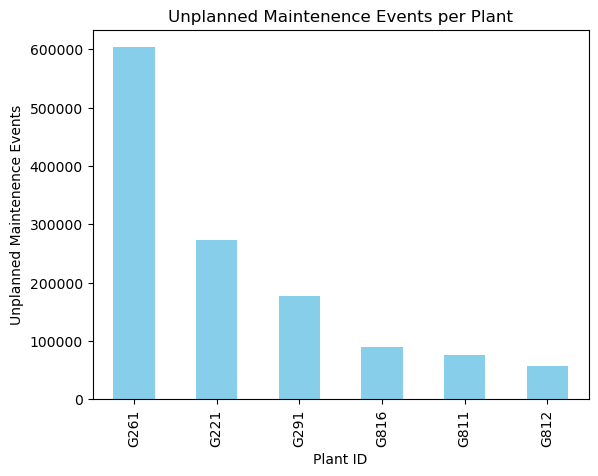

In [ ]:
# plot unplanned maintenence by plant
plantcounts_unplanned = df_unplanned['PLANT_ID'].value_counts()
plantcounts_unplanned.plot(kind='bar',color='skyblue')
plt.xlabel("Plant ID")
plt.ylabel("Unplanned Maintenance Events")
plt.title("Unplanned Maintenance Events per Plant")

Plot provides interesting visualization of the amount of maintenance being carried out at each plant. Plant G261 clearly where the most value could come from improvements in malfunction identification.

Text(0.5, 1.0, 'Planned Maintenance Events per Plant')

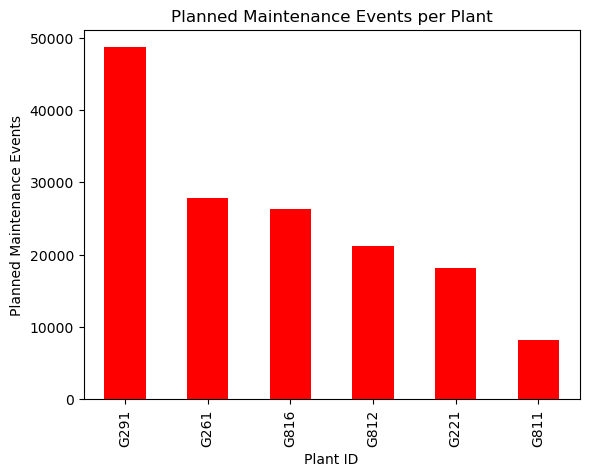

In [ ]:
# plot planned maintenence by plant
plantcounts_planned = df_planned['PLANT_ID'].value_counts()
plantcounts_planned.plot(kind='bar',color='red')
plt.xlabel("Plant ID")
plt.ylabel("Planned Maintenance Events")
plt.title("Planned Maintenance Events per Plant")

When it comes to planned maintenance it is not the plant that experiences the most unplanned issues that is also carrying out the most planned repairs. Could potentially be some correlation there.

EQUIPMENT_ID
300025792.0    3801
300115000.0    3120
300017655.0    2930
300017654.0    2880
300026891.0    2783
300009177.0    2104
300017247.0    1710
300009199.0    1704
300017248.0    1380
300009114.0    1313
300224440.0    1210
300017312.0    1191
300019388.0    1148
300224439.0    1103
300033692.0    1049
300001505.0    1043
300026804.0    1032
Name: count, dtype: int64


Text(0.5, 1.0, 'Most Frequent Unplanned Equipment Malfunctions')

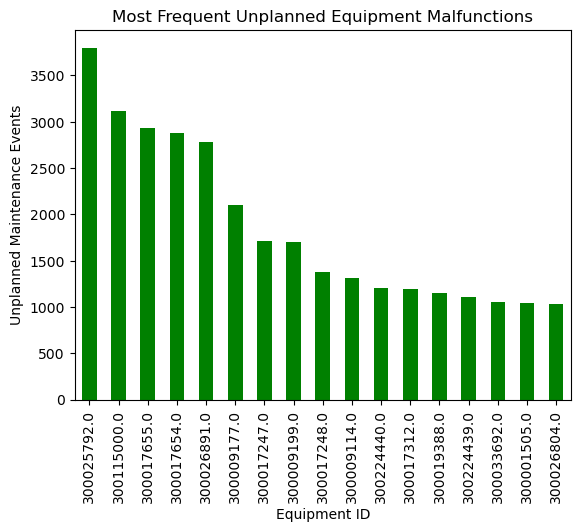

In [ ]:
# plot most frequent equipment malfunctions
equip_ID_counts_unplanned = df_unplanned['EQUIPMENT_ID'].value_counts()
filtered_counts = equip_ID_counts_unplanned[equip_ID_counts_unplanned > 1000]
print(filtered_counts)
filtered_counts.plot(kind='bar',color='green')
plt.xlabel("Equipment ID")
plt.ylabel("Unplanned Maintenance Events")
plt.title("Most Frequent Unplanned Equipment Malfunctions")

This plot shows the number of unplanned maintenance events taking place in association with a malfuntion in a particular piece of equipment. There are hundreds of peices of equipment with a single work orders, so this plot narrows down that value to approximately the top 15 sources of unplanned issues. Improving these numbers at all would be hugely important to the success of this project.

EQUIPMENT_DESC
L1 FILLER_ROTARY_CAN_72_VALVE             3120
L3 PACKR_CASE_WESTROCK_DD1250M            1049
L2 FILLER_ROTARY_BTL_45_VALVE             1043
L2 LABELER_BOTTLE_TRINE 4600_#1            848
L1 FILLER_ROTARY_BTL_60_VALVE              794
L1 PACKR_CASE_WESTROCK_DD1250M             782
L3 PACKER_CASE_TRAY_DOUGLAS                773
L2 LABELER_BOTTLE_TRINE 4600_#2            684
L3 FILLER_ROTARY_BTL_100_VALVE             579
L4 FILLER_ROTARY_CAN_100_VALVE             487
L2 LINE 2 FILLER                           354
LINE 1 LABELER_ROTARY                      327
L2 PALLETIZER_LINE 2_PAI                   316
L1 HEATER_WATER_GAS_DIRECT_FIRE_WARMER     312
L3 PACKER KHS TSP80V                       289
L3 FILLER_ROTARY_CAN_124_VALVE             284
L2 LABELER_LINEAR_BTL_TRINE_WEST_4600G     273
CAN LINE 3 GPI PACKER                      262
L1 / L2 PALLETIZER_ELECPNEU                259
L2 PALLETIZER_T-TEK_TS-0075                235
L3 LABELER_ROTARY                          22

Text(0.5, 1.0, 'Most Frequent Unplanned Equipment Malfunctions')

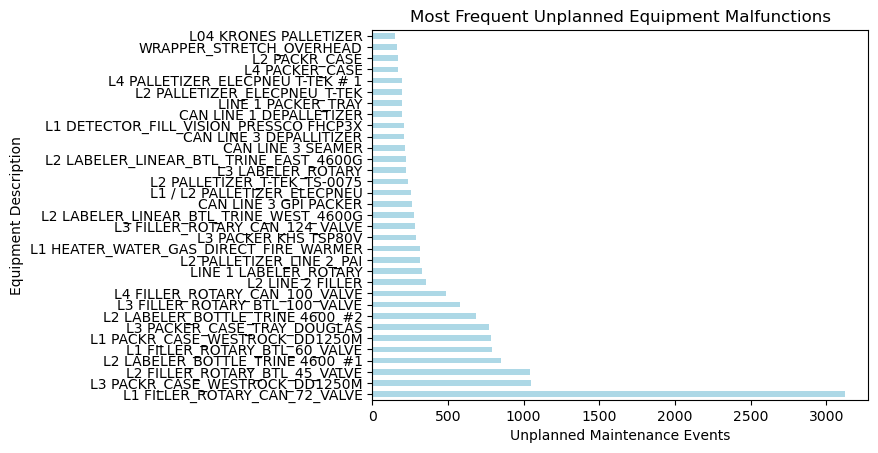

In [ ]:
# plot most frequent equipment malfunctions
equip_desc_counts_unplanned = df_unplanned['EQUIPMENT_DESC'].value_counts()
filtered_counts_equip_desc = equip_desc_counts_unplanned[equip_desc_counts_unplanned > 150]
print(filtered_counts_equip_desc)
filtered_counts_equip_desc.plot(kind='barh',color='lightblue')
plt.xlabel("Unplanned Maintenance Events")
plt.ylabel("Equipment Description")
plt.title("Most Frequent Unplanned Equipment Malfunctions")

Similar to the previous plot, this represents the most frequently problematic peices of equipment in the totality of Swire Coco-Cola's operation. Improving our recognition of when these repairs take place should be paramount.

In [ ]:
# examine the ACTUAL_WORK_IN_MINUTES variable
df_unplanned['ACTUAL_WORK_IN_MINUTES'].describe()

count    1.276877e+06
mean     9.341089e+01
std      8.490851e+02
min      0.000000e+00
25%      5.000000e+00
50%      5.200000e+01
75%      9.500000e+01
max      3.301848e+05
Name: ACTUAL_WORK_IN_MINUTES, dtype: float64

In [ ]:
# explore variable further
print(df_unplanned['ACTUAL_WORK_IN_MINUTES'].isnull().sum())

worktime_min = (df_unplanned['ACTUAL_WORK_IN_MINUTES'].min())
worktime_max = (df_unplanned['ACTUAL_WORK_IN_MINUTES'].max())

print((df_unplanned['ACTUAL_WORK_IN_MINUTES'].min()))
print(df_unplanned['ACTUAL_WORK_IN_MINUTES'].max())

0
0.0
330184.8


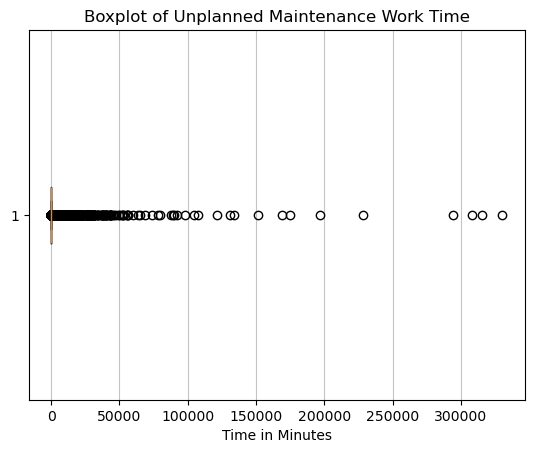

In [ ]:
# plot distribution of ACTUAL_WORK_IN_MINUTES for unplanned data set
plt.boxplot(df_unplanned['ACTUAL_WORK_IN_MINUTES'], vert=False)
plt.title('Boxplot of Unplanned Maintenance Work Time')
plt.xlabel('Time in Minutes')
plt.grid(axis='x',alpha=.75)
plt.show()

The distribution of the target variable ACTUAL_WORK_IN_MINUTES is skewed heavily to the left. There are a few outliers in the data set that will need to be dealt with.

In [ ]:
# same calculations for planned maintenance
print(df_planned['ACTUAL_WORK_IN_MINUTES'].isnull().sum())

plannted_worktime_min = (df_planned['ACTUAL_WORK_IN_MINUTES'].min())
planned_worktime_max = (df_planned['ACTUAL_WORK_IN_MINUTES'].max())

print((df_planned['ACTUAL_WORK_IN_MINUTES'].min()))
print(df_planned['ACTUAL_WORK_IN_MINUTES'].max())

0
0.0
14460.0


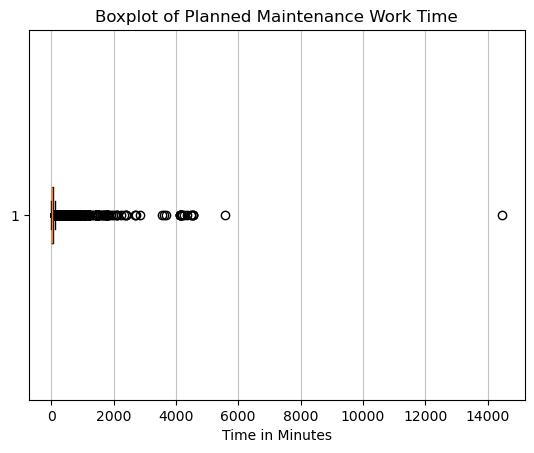

In [ ]:
# plot distribution of variable ACTUAL_WORK_IN_MINUTES for planned dataset
plt.boxplot(df_planned['ACTUAL_WORK_IN_MINUTES'], vert=False)
plt.title('Boxplot of Planned Maintenance Work Time')
plt.xlabel('Time in Minutes')
plt.grid(axis='x',alpha=.75)
plt.show()

Similar to the ACTUAL_WORK_IN_MINUTES distribution for the unplanned maintenance dataset, this variable's distribution is skewed heavily to the left, with multiple outliers.

In [ ]:
# remove outliers from dataset
Q1_unplanned_worktime = df_unplanned['ACTUAL_WORK_IN_MINUTES'].quantile(.25)
Q3_unplanned_worktime = df_unplanned['ACTUAL_WORK_IN_MINUTES'].quantile(.75)
IQR_unplanned = Q3_unplanned_worktime-Q1_unplanned_worktime

lower_bound_unplanned = Q1_unplanned_worktime - 1.5 * IQR_unplanned
upper_bound_unplanned = Q3_unplanned_worktime + 1.5 * IQR_unplanned

print(f'Lower Bound: {lower_bound_unplanned}, Upper Bound: {upper_bound_unplanned}')

filtered_worktime_unplanned = df_unplanned[df_unplanned['ACTUAL_WORK_IN_MINUTES']<= upper_bound_unplanned]
filtered_worktime_unplanned['ACTUAL_WORK_IN_MINUTES'].dtype
print(filtered_worktime_unplanned['ACTUAL_WORK_IN_MINUTES'].describe())

Lower Bound: -130.0, Upper Bound: 230.0
count    1.191732e+06
mean     5.419701e+01
std      5.195503e+01
min      0.000000e+00
25%      1.000000e+00
50%      4.500000e+01
75%      8.500000e+01
max      2.300000e+02
Name: ACTUAL_WORK_IN_MINUTES, dtype: float64


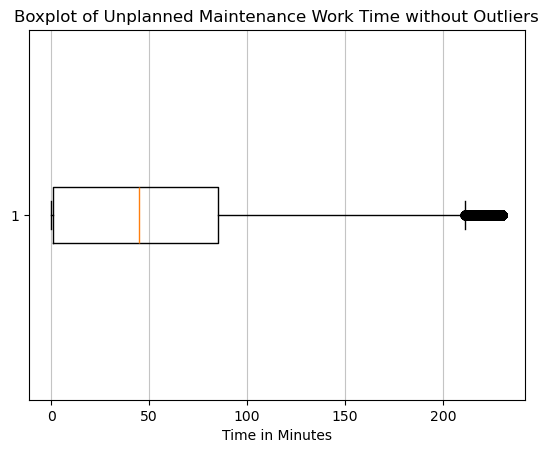

In [ ]:
# plot variable distribution without outliers
plt.boxplot(filtered_worktime_unplanned['ACTUAL_WORK_IN_MINUTES'], vert=False)
plt.title('Boxplot of Unplanned Maintenance Work Time without Outliers')
plt.xlabel('Time in Minutes')
plt.grid(axis='x',alpha=.75)
plt.show()

After removing the outliers from the variable ACTUAL_WORK_IN_MINUTES the visualization of the distribution looks much better.  


In [ ]:
# similar removal of outliers from planned dataset
Q1_planned_worktime = df_planned['ACTUAL_WORK_IN_MINUTES'].quantile(.25)
Q3_planned_worktime = df_planned['ACTUAL_WORK_IN_MINUTES'].quantile(.75)
IQR_planned = Q3_planned_worktime-Q1_planned_worktime

lower_bound_planned = Q1_planned_worktime - 1.5 * IQR_planned
upper_bound_planned = Q3_planned_worktime + 1.5 * IQR_planned

print(f'Lower Bound: {lower_bound_planned}, Upper Bound: {upper_bound_planned}')

filtered_worktime_planned = df_planned[df_planned['ACTUAL_WORK_IN_MINUTES']<= upper_bound_planned]
filtered_worktime_planned['ACTUAL_WORK_IN_MINUTES'].dtype
print(filtered_worktime_planned['ACTUAL_WORK_IN_MINUTES'].describe())

Lower Bound: -52.5, Upper Bound: 127.5
count    142329.000000
mean         36.508138
std          28.285187
min           0.000000
25%          15.000000
50%          30.000000
75%          60.000000
max         126.600000
Name: ACTUAL_WORK_IN_MINUTES, dtype: float64


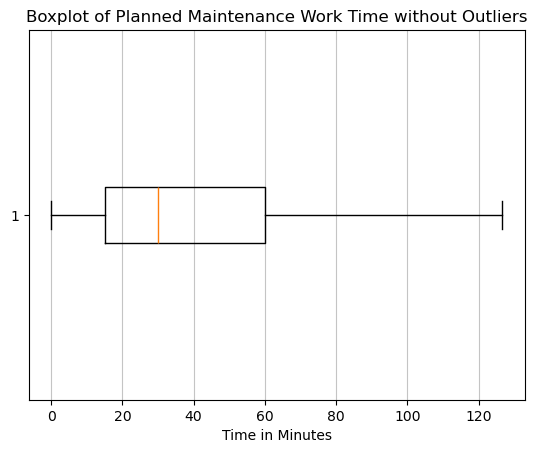

In [ ]:
# plot distribution of variable minus outliers
plt.boxplot(filtered_worktime_planned['ACTUAL_WORK_IN_MINUTES'], vert=False)
plt.title('Boxplot of Planned Maintenance Work Time without Outliers')
plt.xlabel('Time in Minutes')
plt.grid(axis='x',alpha=.75)
plt.show()

Once again visualization of distribution looks much better when removing the outliers from the data set. The average repair time for planned maintenance is over ten minutes less that than of unplanned maintenance. The right extreme value for planned maintenance is also far less than that of unplanned maintenance. Turning as many unplanned maintenance events into planned maintenance events as possible will the be the most effective way for Swire Coca-Cola to prevent unneccesary downtime.

In [ ]:
# generate average repair times for the most frequently broken pieces of equipment
filtered_counts = equip_ID_counts_unplanned[equip_ID_counts_unplanned > 1000]
ids_to_keep = filtered_counts.index
worktime_equipid = df_unplanned[df_unplanned['EQUIPMENT_ID'].isin(ids_to_keep)]
worktime_equipid_grouped = worktime_equipid.groupby('EQUIPMENT_ID')['ACTUAL_WORK_IN_MINUTES'].mean()
print(worktime_equipid_grouped)

EQUIPMENT_ID
300001505.0    160.107958
300009114.0    149.612947
300009177.0    178.558460
300009199.0    146.870423
300017247.0    152.348421
300017248.0    140.464783
300017312.0    201.442821
300017654.0    139.651250
300017655.0    111.770785
300019388.0    247.861150
300025792.0    114.049250
300026804.0     83.001744
300026891.0     88.643694
300033692.0     88.279504
300115000.0     94.478462
300224439.0    101.269447
300224440.0     73.680000
Name: ACTUAL_WORK_IN_MINUTES, dtype: float64


Text(0.5, 1.0, 'Average Unexpected Repair Time for Most Common Equipment Malfunctions')

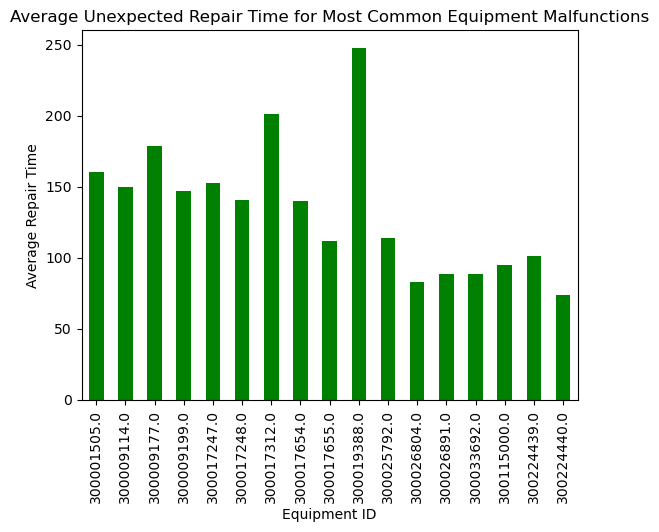

In [ ]:
# plot average amount of time it takes to repair most common malfunctions
worktime_equipid_grouped.plot(kind='bar',color='green')
plt.xlabel("Equipment ID")
plt.ylabel("Average Repair Time")
plt.title("Average Unexpected Repair Time for Most Common Equipment Malfunctions")

This plot represents the average amount of time that is required to repair the most frequently broken pieces of equipment within Swire Coca-Cola's production plants. This not only provides us with insight into what the most time-costly malfunctions are for the company, but also which key pieces of equipment to have spare versions of in order to reduce the amount of time spent on the repairs and ultimately not producing product.